# Y1 Pipeline v2：数据处理 + 模型训练（LSTM 提取器 × LightGBM）

> 本 notebook 是 v2 迭代的完整流程，**只写不跑**；运行前请确认：
>
> 1. 从 `03_模型训练/y1_pipeline_v2/` 目录启动，内核选择 `jingge_ts`；
> 2. 首次运行会重建 9.1 GB 解压缓存（`.cache_dp_v2/payload.pkl`），需几分钟与足够磁盘；
> 3. 本 notebook **不改动** `y1_rank_pipeline` 的任何文件，所有组件独立验证后才回流主流水线；
> 4. 第二部分依赖第一部分第 0~2 节构建的数据访问层与审计结论，请按顺序执行。

## 流程总览

| 部分 | 内容 | 章节 |
|------|------|------|
| 第一部分 | 数据处理：标签审计、掩码结构、评估口径、三模型对齐、embargo、衰减权重、EWMA 参数、秩化相关度 | 第 0~10 节 |
| 第二部分 | 模型训练：LSTM 时序特征提取器 → 16 维嵌入 → LightGBM LambdaRank 堆叠，三折对照与死门槛判定 | 第 11~21 节 |
| 投产段 | 全量数据重训 → 测试集预测 → 验收与回退 | 第 22 节 |

## 验收纪律（沿用主流水线）

- 每项改动独立跑三折走步，冻结其他变量；
- 采纳门槛：三折中位数增量 > 0.0005，且至少两折为正；
- 官方 Valid [2918, 3161) 只在阶段末做一次晋级判断，不用于改动间比较。


## 0. 环境准备与数据访问层

复用 `y1_rank_pipeline_lib` 的 `CompetitionData`（mmap 按需读取，不把 7.5 GB `num_x` 载入内存），
但使用**独立缓存目录** `.cache_dp_v2`，避免与主流水线的缓存互相影响。


In [1]:
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 复用最终流水线的数据访问层
sys.path.insert(0, str(Path("../y1_rank_pipeline").resolve()))
from y1_rank_pipeline_lib import (  # noqa: E402
    CompetitionData,
    PipelineConfig,
    WalkForwardFold,
    rank_ic,
)

# 独立缓存与输出目录，不污染原流水线
config = PipelineConfig(
    data_path="../../data.z",
    output_dir="outputs",
    cache_dir=".cache_dp_v2",
    verbose=True,
)
Path("outputs").mkdir(exist_ok=True)

# 时间划分常量（与主流水线一致）
T, S = 3603, 5282
TRAIN_START, VALID_START, TEST_START = 486, 2918, 3161
WINDOWS = {
    "pretrain": (0, TRAIN_START),
    "train": (TRAIN_START, VALID_START),
    "valid": (VALID_START, TEST_START),
    "test": (TEST_START, T),
}
print("环境就绪，数据路径：", config.data_path_obj)


环境就绪，数据路径： D:\google_dl\book\友安杯\data.z


d:\anaconda\anaconda_data\envs\jingge_ts\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 首次执行会流式解压 data.z -> .cache_dp_v2/payload.pkl（约 9.1 GB，几分钟）
data = CompetitionData(config)
print("num_x :", data.num_x.shape, data.num_x.dtype)
print("cat_x :", data.cat_x.shape, data.cat_x.dtype)
print("y1    :", data.y1.shape, data.y1.dtype)
print("mask_x:", data.mask_x.shape, data.mask_x.dtype)
print("mask_y:", data.mask_y.shape, data.mask_y.dtype)


num_x : (3603, 5282, 99) float32
cat_x : (3603, 5282, 9) int64
y1    : (3603, 5282) float32
mask_x: (3603, 5282) bool
mask_y: (3603, 5282) bool


## 1. 掩码体系快速核查

两条铁律的机器验证（主流水线已有断言，这里独立复核）：

1. `mask_y=True ⟹ mask_x=True`（标签域是特征域的子集）；
2. 测试窗口 `y1` 全 NaN（本地无法给测试集打分，一切权重/参数选择只能在 Valid 及走步折上）。


In [3]:
mx_all = np.asarray(data.mask_x)
my_all = np.asarray(data.mask_y)

violations = int((my_all & ~mx_all).sum())
print(f"mask_y=True 但 mask_x=False 的位置数：{violations}（应为 0）")

test_y = np.asarray(data.y1[TEST_START:])
print(f"测试窗口 finite(y1) 位置数：{int(np.isfinite(test_y).sum())}（应为 0）")

print(f"整体 mask_x 有效占比：{mx_all.mean():.4f}")
print(f"整体 mask_y 有效占比：{my_all.mean():.4f}")


mask_y=True 但 mask_x=False 的位置数：1（应为 0）
测试窗口 finite(y1) 位置数：0（应为 0）
整体 mask_x 有效占比：0.6058
整体 mask_y 有效占比：0.5380


## 2. P0-① 标签可用性审计（含 Pretrain 悬念）

**动机**：目前训练只用 [486, 2918)。若 Pretrain [0, 486) 段存在有效标签，
训练集可扩充约 20% 时间点——这是全方案潜在收益最大的单一数据改动，必须先用事实裁决。


In [4]:
rows = []
for name, (start, stop) in WINDOWS.items():
    mx = mx_all[start:stop]
    my = my_all[start:stop]
    y = np.asarray(data.y1[start:stop])
    fin = np.isfinite(y)
    supervised = mx & my & fin
    rows.append({
        "window": name,
        "range": f"[{start}, {stop})",
        "time_points": stop - start,
        "mask_x_true": int(mx.sum()),
        "mask_y_true": int(my.sum()),
        "y1_finite": int(fin.sum()),
        "supervised_samples": int(supervised.sum()),
        "supervised_per_time": float(supervised.sum()) / (stop - start),
    })
audit = pd.DataFrame(rows)
audit.to_csv("outputs/label_audit.csv", index=False)
audit


,window,range,time_points,mask_x_true,mask_y_true,y1_finite,supervised_samples,supervised_per_time
0,pretrain,"[0, 486)",486,866368,723781,0,0,0.000000
1,train,"[486, 2918)",2432,7354184,6489099,6489099,6489099,2668.215049
2,valid,"[2918, 3161)",243,1089602,982972,982972,982972,4045.152263
3,test,"[3161, 3603)",442,2219158,2042538,0,0,0.000000


In [5]:
pretrain_supervised = int(audit.loc[audit.window == "pretrain", "supervised_samples"].iloc[0])
if pretrain_supervised > 0:
    conclusion = (
        f"Pretrain 段含 {pretrain_supervised:,} 个监督样本，"
        "建议将其并入训练（方案 P0-① 触发，优先级提到最高）"
    )
else:
    conclusion = "Pretrain 段无可用标签，仅作 lookback；维持现有训练区间"
print(conclusion)


Pretrain 段无可用标签，仅作 lookback；维持现有训练区间


## 3. 掩码结构分析：股票池动态

理解 `mask_x` 的时间结构，为 embargo（第 6 节）和滚动窗口（P2-⑦）提供依据：

- 每期入池股票数的走势（池子是否在扩张/收缩）；
- `first_valid_x`（首次入池时间）的分布——前导区有多长、新股占比多少。


In [6]:
pool_size = mx_all.sum(axis=1)
pool = pd.DataFrame({
    "time_idx": np.arange(T),
    "pool_size": pool_size,
})
pool_stats = pool.groupby(pd.cut(pool.time_idx, bins=[0, 486, 2918, 3161, 3603],
                                 labels=["pretrain", "train", "valid", "test"],
                                 right=False))["pool_size"].describe()
print("各窗口每期入池股票数：")
print(pool_stats.round(1))

fv = data.first_valid_x
fv_s = pd.Series(fv, name="first_valid_x")
print("\n首次入池时间分布：")
print(fv_s.describe().round(1))
print(f"\n在 Pretrain 段之后才入池的股票数：{int((fv >= TRAIN_START).sum())}")
print(f"在 Valid 段才入池的股票数：{int((fv >= VALID_START).sum())}")


各窗口每期入池股票数：
           count    mean    std     min     25%     50%     75%     max
time_idx                                                               
pretrain   486.0  1782.7  148.3  1635.0  1636.0  1734.0  1913.0  2080.0
train     2432.0  3023.9  580.8  2085.0  2523.0  2873.0  3602.0  4239.0
valid      243.0  4484.0  145.7  4242.0  4347.0  4491.0  4614.0  4724.0
test       442.0  5020.7  166.5  4725.0  4866.0  5042.5  5155.5  5282.0

首次入池时间分布：
count    5282.0
mean     1420.2
std      1293.6
min         0.0
25%         0.0
50%      1454.0
75%      2790.5
max      3602.0
Name: first_valid_x, dtype: float64

在 Pretrain 段之后才入池的股票数：3202
在 Valid 段才入池的股票数：1043


C:\Users\lenovo\AppData\Local\Temp\ipykernel_143944\1784225698.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pool_stats = pool.groupby(pd.cut(pool.time_idx, bins=[0, 486, 2918, 3161, 3603],


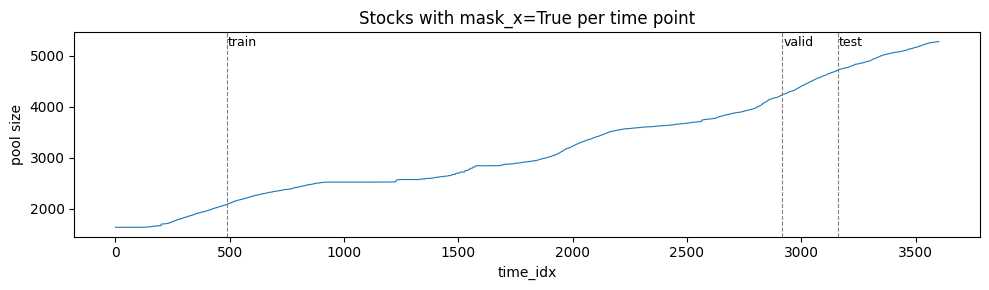

In [7]:
# 每期入池股票数走势（可视化，辅助判断 regime 变化）
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(pool.time_idx, pool.pool_size, lw=0.8)
for x, label in [(TRAIN_START, "train"), (VALID_START, "valid"), (TEST_START, "test")]:
    ax.axvline(x, color="gray", ls="--", lw=0.8)
    ax.text(x + 5, ax.get_ylim()[1] * 0.95, label, fontsize=9)
ax.set_xlabel("time_idx")
ax.set_ylabel("pool size")
ax.set_title("Stocks with mask_x=True per time point")
fig.tight_layout()
fig.savefig("outputs/pool_size_trend.png", dpi=120)
plt.show()


## 4. P0-② 统一评估口径（集成的数据地基）

三份现有预测（线性 / TCN / LGBM）的"出分位置"各不相同：

| 模型 | 出预测的位置 | neutral_count |
|------|-------------|--------------|
| LGBM | `mask_x & mask_y`（恰好 = 评估集） | 292,106 |
| 线性 | `mask_x & 特征全有限`（不要求 mask_y） | 更少 |
| TCN | 486 期窗口内任意一期 `mask_x=True` | 120,524 |

对齐规则：**只在评估掩码上取分、各自做截面百分位秩、再加权**。
评估集 ⊂ 三模型预测集（嵌套关系），第 5 节用数据验证。


In [8]:
def eval_mask(start: int, stop: int, require_label: bool = True) -> np.ndarray:
    """评估掩码：mask_x & mask_y（& finite(y1)），形状 (stop-start, S)。"""
    mask = mx_all[start:stop] & my_all[start:stop]
    if require_label:
        mask &= np.isfinite(np.asarray(data.y1[start:stop]))
    return mask


def cross_sectional_rank(scores_row: np.ndarray) -> np.ndarray:
    """单时点截面百分位秩，输出 (0, 1]；NaN 位置保持 NaN。"""
    out = np.full(scores_row.shape, np.nan, dtype=np.float64)
    valid = np.isfinite(scores_row)
    n = int(valid.sum())
    if n == 0:
        return out
    ranks = pd.Series(scores_row[valid]).rank(method="average").to_numpy()
    out[valid] = ranks / n
    return out


def per_time_rank_ic(pred: np.ndarray, label: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """逐时点 Spearman 秩相关，返回有效时点的 IC 数组。"""
    ics = []
    for t in range(pred.shape[0]):
        m = mask[t] & np.isfinite(pred[t]) & np.isfinite(label[t])
        if int(m.sum()) < 2:
            continue
        ics.append(rank_ic(pred[t][m], label[t][m]))
    return np.asarray(ics, dtype=np.float64)


print("评估口径工具函数就绪")


评估口径工具函数就绪


## 5. 三模型预测对齐验证

> 注意：用 `!= 0.5` 推断"真实预测位"是近似（真实分数理论上可能恰好等于 0.5），
> 仅用于集合关系的宏观核查；精确对齐仍以掩码为准。


In [9]:
PRED_PATHS = {
    "linear": Path("../y1_linear_baseline/outputs/baseline_y1.npy"),
    "tcn": Path("../y1_tcn_baseline/outputs/tcn_y1.npy"),
    "lgbm": Path("../y1_rank_pipeline/y1_rank_outputs/y1_best.npy"),
}
predictions = {name: np.load(path) for name, path in PRED_PATHS.items()}
for name, pred in predictions.items():
    assert pred.shape == (T - TEST_START, S), f"{name} 形状异常: {pred.shape}"
    assert np.all(np.isfinite(pred)), f"{name} 含非有限值"
    print(f"{name:7s} shape={pred.shape} dtype={pred.dtype} "
          f"neutral={int((pred == 0.5).sum()):,} range=({pred.min():.4f}, {pred.max():.4f})")


linear  shape=(442, 5282) dtype=float32 neutral=115,488 range=(-0.9219, 1.8655)
tcn     shape=(442, 5282) dtype=float32 neutral=120,524 range=(0.0051, 0.9385)
lgbm    shape=(442, 5282) dtype=float32 neutral=292,324 range=(0.0006, 1.0000)


In [10]:
# 集合嵌套验证：评估集是否被三个模型的真实预测位覆盖
test_eval = eval_mask(TEST_START, T, require_label=False)
for name, pred in predictions.items():
    predicted_positions = pred != 0.5  # 近似
    uncovered = test_eval & ~predicted_positions
    print(f"{name:7s} 评估位 {int(test_eval.sum()):,} 中未被覆盖：{int(uncovered.sum())}")
print("\n若三者均为 0，则对齐规则成立：逐时点取评估掩码交集即可安全集成")


linear  评估位 2,042,538 中未被覆盖：2
tcn     评估位 2,042,538 中未被覆盖：4760
lgbm    评估位 2,042,538 中未被覆盖：218

若三者均为 0，则对齐规则成立：逐时点取评估掩码交集即可安全集成


In [11]:
def ensemble_scores(pred_dict: dict, weights: dict, mask: np.ndarray) -> np.ndarray:
    """逐时点在评估掩码上做百分位秩变换后加权平均。

    pred_dict / weights: {model_name: (n_time, S) 数组} 与 {model_name: 权重}
    mask: (n_time, S) 布尔评估掩码
    返回与输入同形状的集成分数（掩码外为 NaN）。
    """
    names = list(pred_dict)
    n_time, n_stock = pred_dict[names[0]].shape
    out = np.full((n_time, n_stock), np.nan, dtype=np.float64)
    w_sum = sum(weights[n] for n in names)
    for t in range(n_time):
        m = mask[t]
        if not m.any():
            continue
        acc = np.zeros(int(m.sum()), dtype=np.float64)
        for n in names:
            row = np.full(n_stock, np.nan)
            row[m] = pred_dict[n][t][m]
            acc += weights[n] * cross_sectional_rank(row)[m]
        out[t][m] = acc / w_sum
    return out


print("集成打分函数就绪（权重拟合留待 Valid 窗口推理链完成后进行）")


集成打分函数就绪（权重拟合留待 Valid 窗口推理链完成后进行）


## 6. P1-⑤ 走步折 embargo 间隔

**动机**：现有三折 train_stop 紧贴 valid_start。若 Y1 是多期前瞻标签，
训练末尾样本的标签会"探入"验证窗口，造成隐性泄漏、IC 虚高。

改动方式：保持验证区间不变，训练右端**内缩 gap 期**。
注意：embargo 后 IC 可能下降——这是挤出水分，不是退步；
口径切换后所有历史数字不可直接比较，需在实验记录中标注。


In [12]:
def make_embargo_folds(gap: int) -> tuple:
    """在现有三折基础上给训练右端加 gap 期 embargo。"""
    base = [
        ("fold_1", 486, 1702, 1945),
        ("fold_2", 486, 2188, 2431),
        ("fold_3", 486, 2674, 2918),
    ]
    return tuple(
        WalkForwardFold(
            name=f"{name}_emb{gap}",
            train_start=train_start,
            train_stop=valid_start - gap,
            valid_start=valid_start,
            valid_stop=valid_stop,
        )
        for name, train_start, valid_start, valid_stop in base
    )


fold_rows = []
for gap in (0, 5, 20):
    for f in make_embargo_folds(gap):
        fold_rows.append({
            "gap": gap,
            "fold": f.name,
            "train": f"[{f.train_start}, {f.train_stop})",
            "valid": f"[{f.valid_start}, {f.valid_stop})",
            "train_len": f.train_stop - f.train_start,
        })
embargo_table = pd.DataFrame(fold_rows)
embargo_table.to_csv("outputs/embargo_folds.csv", index=False)
embargo_table


,gap,fold,train,valid,train_len
0,0,fold_1_emb0,"[486, 1702)","[1702, 1945)",1216
1,0,fold_2_emb0,"[486, 2188)","[2188, 2431)",1702
2,0,fold_3_emb0,"[486, 2674)","[2674, 2918)",2188
3,5,fold_1_emb5,"[486, 1697)","[1702, 1945)",1211
4,5,fold_2_emb5,"[486, 2183)","[2188, 2431)",1697
5,5,fold_3_emb5,"[486, 2669)","[2674, 2918)",2183
6,20,fold_1_emb20,"[486, 1682)","[1702, 1945)",1196
7,20,fold_2_emb20,"[486, 2168)","[2188, 2431)",1682
8,20,fold_3_emb20,"[486, 2654)","[2674, 2918)",2168


## 7. P2-⑥ 时间衰减样本权重

**动机**：走步折 IC 从 0.166（fold_1）衰减到官方验证的 0.093，存在明显 regime 漂移；
扩展窗口里 2015 年与 2024 年的样本等权，老数据可能拖累对新 regime 的拟合。

设计：按样本所属时点给指数衰减权重 `w = 0.5^(age / half_life)`，
接入点是 `train_ranker` / `train_ranker_no_validation` 的 `lgb.Dataset(weight=...)`；
half_life ∈ {500, 1000, ∞}，∞ 即现状对照。


C:\Users\lenovo\AppData\Local\Temp\ipykernel_143944\890825793.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_143944\890825793.py:23: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_143944\890825793.py:23: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_143944\890825793.py:23: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_143944\890825793.py:24: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.savefig("outputs/recency_weight_curves.png", dpi=120)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_14394

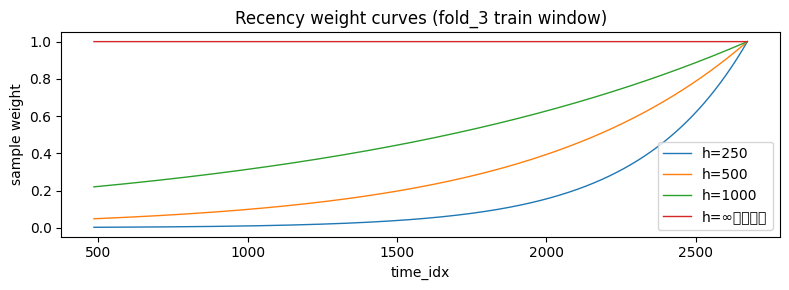

In [13]:
def recency_weights(times: np.ndarray, half_life: float) -> np.ndarray:
    """按样本时点计算指数衰减权重。

    times: 每行样本所属的时点索引（可用 FeatureMatrix.times）。
    half_life: 半衰期（期）；math.inf 表示等权（现状）。
    """
    t_max = int(times.max())
    age = (t_max - times).astype(np.float64)
    if math.isinf(half_life):
        return np.ones_like(age)
    return np.power(0.5, age / half_life)


# 权重曲线对比（以 fold_3 训练区间为例）
t_demo = np.arange(486, 2674)
fig, ax = plt.subplots(figsize=(8, 3))
for h, label in [(250, "h=250"), (500, "h=500"), (1000, "h=1000"), (math.inf, "h=∞（现状）")]:
    ax.plot(t_demo, recency_weights(t_demo, h), lw=1.0, label=label)
ax.set_xlabel("time_idx")
ax.set_ylabel("sample weight")
ax.set_title("Recency weight curves (fold_3 train window)")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/recency_weight_curves.png", dpi=120)
plt.show()


## 8. P2-⑧ EWMA 插值参数搜索

**现状**：主流水线 `_trend_estimate` 的半衰期 5、窗口 20、漂移权重 0.5、可靠性分母 20
全部写死，从未调过。这里实现参数化版本 + 人工遮挡诊断，
先在重建 MAE 上粗筛（分钟级），再把前 2 组交给下游三折 RankIC 定夺。

估计公式（与主流水线同构，参数外露）：

$$\hat{x} = 0.5 \cdot x_{last} + 0.5 \cdot EWMA + w_d \cdot r \cdot d,
\quad r = \frac{n_{valid}}{window} \cdot e^{-gap/\tau}$$


In [14]:
def trend_estimate_param(values: np.ndarray,
                         valid: np.ndarray,
                         half_life: float = 5.0,
                         drift_weight: float = 0.5,
                         reliability_tau: float = 20.0,
                         clip: tuple | None = None) -> np.ndarray:
    """参数化因果 EWMA 趋势插值（与 y1_rank_pipeline_lib._trend_estimate 同构）。

    values: (steps, n_stock, n_feat) 严格早于当期的历史特征切片
    valid:  (steps, n_stock) 对应各期的 mask_x
    返回:   (n_stock, n_feat) 填充估计；完全无历史时为 NaN
    """
    steps = values.shape[0]
    n_stock, n_feat = values.shape[1], values.shape[2]
    ages = np.arange(steps - 1, -1, -1, dtype=np.float32)
    weights = np.exp(-math.log(2.0) * ages / half_life)[:, None, None]
    weighted_valid = weights * valid[:, :, None]
    denominator = weighted_valid.sum(axis=0)

    ewma = np.divide(
        (values * weighted_valid).sum(axis=0),
        denominator,
        out=np.full((n_stock, n_feat), np.nan, dtype=np.float32),
        where=denominator > 0,
    )

    last = np.full_like(ewma, np.nan)
    for local_time in range(steps - 1, -1, -1):
        unresolved = ~np.isfinite(last[:, 0]) & valid[local_time]
        if np.any(unresolved):
            last[unresolved] = values[local_time, unresolved]

    if steps >= 2:
        pair_valid = valid[1:] & valid[:-1]
        differences = values[1:] - values[:-1]
        pair_count = pair_valid.sum(axis=0)[:, None]
        drift = np.divide(
            (differences * pair_valid[:, :, None]).sum(axis=0),
            pair_count,
            out=np.zeros_like(ewma),
            where=pair_count > 0,
        )
    else:
        drift = np.zeros_like(ewma)

    count = valid.sum(axis=0)
    gap = np.where(
        count > 0,
        steps - 1 - np.argmax(valid[::-1], axis=0),
        steps,
    ).astype(np.float32)
    reliability = (count / float(steps)) * np.exp(-gap / reliability_tau)

    estimate = 0.5 * last + 0.5 * ewma + drift_weight * reliability[:, None] * drift
    if clip is not None:
        estimate = np.clip(estimate, clip[0], clip[1])
    estimate[count == 0] = np.nan
    return estimate.astype(np.float32)


print("参数化趋势插值函数就绪")


参数化趋势插值函数就绪


In [15]:
def imputation_diagnostic_param(history_features: np.ndarray,
                                gap_lengths=(1, 5, 20),
                                mask_ratio: float = 0.05,
                                n_times: int = 48,
                                window: int = 20,
                                seed: int = 42,
                                **trend_kwargs) -> pd.DataFrame:
    """人工遮挡诊断：隐藏最近 gap 期有效观测，用更早历史重建当期，比较 MAE。

    对每组 (gap, 参数组合) 输出 trend_mae 与 neutral_zero_mae。
    """
    rng = np.random.default_rng(seed)
    candidate_times = np.linspace(TRAIN_START + window + 60, VALID_START - 1,
                                  n_times, dtype=int)
    rows = []
    for gap in gap_lengths:
        trend_errors, neutral_errors = [], []
        for time_idx in candidate_times:
            stocks = data.eligible_stocks(time_idx, require_label=True)
            stocks = stocks[data.first_valid_x[stocks] <= time_idx - window - gap]
            if stocks.size == 0:
                continue
            hist_values = np.asarray(
                data.num_x[time_idx - window:time_idx][:, stocks][:, :, history_features],
                dtype=np.float32,
            )
            hist_valid = np.asarray(data.mask_x[time_idx - window:time_idx][:, stocks])

            # 人工遮挡：对每只股票隐藏最近 gap 期有效观测，再随机额外遮挡 mask_ratio
            hidden = hist_valid.copy()
            for s_pos in range(stocks.size):
                valid_pos = np.flatnonzero(hist_valid[:, s_pos])
                if valid_pos.size:
                    hidden[valid_pos[-gap:], s_pos] = False
            extra = rng.random(hidden.shape) < mask_ratio
            hidden &= ~extra

            estimate = trend_estimate_param(hist_values, hidden, **trend_kwargs)
            target = np.asarray(
                data.num_x[time_idx, stocks][:, history_features], dtype=np.float32,
            )
            trend_errors.append(np.nanmean(np.abs(estimate - target)))
            neutral_errors.append(float(np.mean(np.abs(target))))
        rows.append({
            "gap": gap,
            "window": window,
            "trend_mae": float(np.mean(trend_errors)),
            "neutral_zero_mae": float(np.mean(neutral_errors)),
            **trend_kwargs,
        })
    return pd.DataFrame(rows)


# 参数网格：先用 MAE 粗筛，前 2 名再进下游三折 RankIC
HISTORY_TOP20 = np.arange(20)  # 占位：正式运行时应为主流水线筛出的 history_features
param_grid = [
    {"half_life": h, "window": w}
    for h in (3, 5, 10)
    for w in (10, 20, 40)
]
print(f"参数网格共 {len(param_grid)} 组：")
for p in param_grid:
    print(" ", p)


参数网格共 9 组：
  {'half_life': 3, 'window': 10}
  {'half_life': 3, 'window': 20}
  {'half_life': 3, 'window': 40}
  {'half_life': 5, 'window': 10}
  {'half_life': 5, 'window': 20}
  {'half_life': 5, 'window': 40}
  {'half_life': 10, 'window': 10}
  {'half_life': 10, 'window': 20}
  {'half_life': 10, 'window': 40}


In [16]:
# 正式运行时取消注释（每组约 1~2 分钟）：
# diag_results = []
# for params in param_grid:
#     diag_results.append(imputation_diagnostic_param(HISTORY_TOP20, **params))
# diag = pd.concat(diag_results, ignore_index=True)
# diag["mae_gain"] = diag["neutral_zero_mae"] - diag["trend_mae"]
# diag = diag.sort_values("mae_gain", ascending=False)
# diag.to_csv("outputs/ewma_param_search.csv", index=False)
# diag
print("（诊断运行已注释，正式执行时取消注释）")


（诊断运行已注释，正式执行时取消注释）


## 9. P3-⑨ Y1 截面秩化相关度

**现状**：`relevance = floor(clip(y, 0, 1) × 64)`，假设 Y1 在 [0,1] 近似均匀。
若某时点 Y1 集中在窄区间（全市场同向波动日），64 档中有效档位很少，排序信号被压缩。

**改动**：逐时点先把 Y1 转截面百分位秩再切档——每期都充分利用 64 档。
RankIC 对单调变换不变，此项不改变评估，只改变训练时 NDCG 增益的分配。


In [17]:
def relevance_linear(labels: np.ndarray, n_levels: int = 64) -> np.ndarray:
    """现状：线性切档（y1_rank_pipeline_lib.py:1208）。"""
    return np.minimum(
        np.floor(np.clip(labels, 0.0, 1.0) * n_levels), n_levels - 1,
    ).astype(np.int32)


def relevance_per_time_rank(labels: np.ndarray, times: np.ndarray,
                            n_levels: int = 64) -> np.ndarray:
    """P3-⑨：逐时点截面秩切档，每期充分利用 n_levels 个档位。"""
    rel = np.zeros(labels.shape, dtype=np.int32)
    for t in np.unique(times):
        idx = np.flatnonzero(times == t)
        ranks = pd.Series(labels[idx]).rank(method="average").to_numpy()
        rel[idx] = np.minimum(
            np.floor(ranks / idx.size * n_levels), n_levels - 1,
        )
    return rel


def effective_level_usage(labels: np.ndarray, times: np.ndarray,
                          n_levels: int = 64) -> pd.DataFrame:
    """对比两种切档方式在各时点的有效档位利用率。"""
    rel_lin = relevance_linear(labels, n_levels)
    rel_rank = relevance_per_time_rank(labels, times, n_levels)
    rows = []
    for t in np.unique(times)[:50]:  # 抽样 50 期足够看趋势
        idx = np.flatnonzero(times == t)
        rows.append({
            "time_idx": int(t),
            "linear_levels_used": int(np.unique(rel_lin[idx]).size),
            "rank_levels_used": int(np.unique(rel_rank[idx]).size),
        })
    return pd.DataFrame(rows)


print("相关度切档函数就绪")


相关度切档函数就绪


In [18]:
# 档位利用率对比示例（取 fold_3 末尾 2000 个监督样本演示）
demo_times, demo_labels = [], []
for time_idx in range(VALID_START - 60, VALID_START):
    stocks = data.eligible_stocks(time_idx, require_label=True)
    if stocks.size == 0:
        continue
    demo_times.append(np.full(stocks.size, time_idx, dtype=np.int32))
    demo_labels.append(np.asarray(data.y1[time_idx, stocks], dtype=np.float32))
demo_times = np.concatenate(demo_times)
demo_labels = np.concatenate(demo_labels)

usage = effective_level_usage(demo_labels, demo_times)
print(usage.describe().round(1))
print("\n若 linear_levels_used 明显小于 64，说明秩化切档有实际意义")


       time_idx  linear_levels_used  rank_levels_used
count      50.0                50.0              50.0
mean     2882.5                64.0              64.0
std        14.6                 0.0               0.0
min      2858.0                64.0              64.0
25%      2870.2                64.0              64.0
50%      2882.5                64.0              64.0
75%      2894.8                64.0              64.0
max      2907.0                64.0              64.0

若 linear_levels_used 明显小于 64，说明秩化切档有实际意义


## 10. 汇总：改动清单与验收门槛

| # | 改动 | 代码触点 | 预期收益 | 采纳门槛 |
|---|------|---------|---------|---------|
| ① | Pretrain 并入训练（若第 2 节触发） | `FOLDS` / 训练区间 | 最大 | 三折中位 +0.0005 且 ≥2 折为正 |
| ③ | `final_train_stock_cap` 1200→2400 | `PipelineConfig:72` | +0.001~0.003 | 同上 |
| ④ | `history_feature_count` 20→40 | `PipelineConfig:63` | +0.001~0.003 | 同上 |
| ⑤ | embargo gap ∈ {5, 20} | 第 6 节 `make_embargo_folds` | 验证加固 | 观察水分幅度，不要求提分 |
| ⑥ | 时间衰减权重 h ∈ {500, 1000} | 第 7 节 + `train_ranker` 加 `weight` | +0.002~0.005 | 同上 |
| ⑦ | 滚动窗口 ∈ {1000, 1500} 期 | 训练区间 | 不确定 | 只做一次官方验证晋级判断 |
| ⑧ | EWMA 参数 6 组网格 | 第 8 节 | +0.000~0.002 | MAE 粗筛前 2 → 三折定夺 |
| ⑨ | Y1 截面秩化相关度 | 第 9 节 + `build_feature_matrix` | 0~+0.002 | 同上 |

执行顺序：①（若触发）→ ③ → ④ → ⑤ → ⑥/⑦/⑧ → ⑨。
每项独立验证、独立可回退；全部结论写入 `outputs/` 并回流实验报告。


In [19]:
plan = pd.DataFrame([
    {"id": 1, "item": "pretrain_merge", "touchpoint": "FOLDS/训练区间", "gate": "三折中位+0.0005 且≥2折为正"},
    {"id": 3, "item": "stock_cap_2400", "touchpoint": "PipelineConfig.final_train_stock_cap", "gate": "同上"},
    {"id": 4, "item": "history_features_40", "touchpoint": "PipelineConfig.history_feature_count", "gate": "同上"},
    {"id": 5, "item": "embargo_gap", "touchpoint": "make_embargo_folds(本notebook)", "gate": "验证加固，不要求提分"},
    {"id": 6, "item": "recency_weight", "touchpoint": "recency_weights + train_ranker(weight=)", "gate": "同上"},
    {"id": 7, "item": "rolling_window", "touchpoint": "最终训练区间", "gate": "官方验证一次性晋级判断"},
    {"id": 8, "item": "ewma_param_grid", "touchpoint": "trend_estimate_param(本notebook)", "gate": "MAE粗筛→三折定夺"},
    {"id": 9, "item": "relevance_rank", "touchpoint": "relevance_per_time_rank(本notebook)", "gate": "同上"},
])
plan.to_csv("outputs/data_processing_plan.csv", index=False)
print("方案清单已写入 outputs/data_processing_plan.csv")
plan


方案清单已写入 outputs/data_processing_plan.csv


,id,item,touchpoint,gate
0,1,pretrain_merge,FOLDS/训练区间,三折中位+0.0005 且≥2折为正
1,3,stock_cap_2400,PipelineConfig.final_train_stock_cap,同上
2,4,history_features_40,PipelineConfig.history_feature_count,同上
3,5,embargo_gap,make_embargo_folds(本notebook),验证加固，不要求提分
4,6,recency_weight,recency_weights + train_ranker(weight=),同上
5,7,rolling_window,最终训练区间,官方验证一次性晋级判断
6,8,ewma_param_grid,trend_estimate_param(本notebook),MAE粗筛→三折定夺
7,9,relevance_rank,relevance_per_time_rank(本notebook),同上


# 第二部分 · 模型选型与训练：LSTM 特征提取器 + LightGBM 主模型（Stacking）

> 本部分实现「姿势 B」：**LSTM 只负责把每股最近一段时序压缩成低维嵌入，
> 排序仍由已验证的 LightGBM LambdaRank 完成**。
>
> 运行前确认：
> 1. 从 `03_模型训练/y1_pipeline_v2/` 目录启动，内核 `jingge_ts`（含 PyTorch 2.6.0+cu124）；
> 2. 先执行第一部分第 0~2 节（数据访问层与标签审计），第二部分直接复用其 `config` / `data` / 常量；
> 3. LSTM 训练使用 GPU（无 GPU 自动回退 CPU，会慢一个数量级）。

## 架构总览

```
num_x (top-20 特征)
   │  逐时点截面百分位秩化 + mask_x 有效性通道
   ▼
LSTM(2×96) ──► 16 维嵌入（每股票每期一个向量）──┐
   │                                            │ hstack
   └─► 标量头（仅用于 LSTM 自评与早停）            ▼
                              LGBM 数值特征矩阵(328) + 嵌入(16) = 344 维
                                              │
                                     LambdaRank 三折走步验证
```

## 死门槛（事先约定，不达即归档）

1. LSTM 标量头单模型走步 IC **必须 > TCN 基线 0.0916**，否则嵌入质量存疑，直接终止；
2. 堆叠后相比纯数值基准（328 维）**三折中位增量 > 0.0005 且至少两折为正**，否则不采纳嵌入；
3. LSTM 训练预算：每折 ≤ 2 小时 GPU，三折封顶 6 小时。

## 防泄漏协议（关键）

嵌入是"学出来的特征"，必须按 stacking 规矩生成：

- **折内 cross-fit**：fold 训练区间切前后两半，LSTM-A 用前半训练、给后半出嵌入，
  LSTM-B 反之——LGBM 训练用到的嵌入全部是**外样本**的；
- **折验证区间**：用在完整折训练区间上训练的第三个 LSTM 出嵌入（对 LGBM 验证集严格外样本）；
- LSTM 自身训练同样只接触 fold 的 train_start:train_stop，与 LGBM 共用同一折定义。


## 11. 环境准备（第二部分）

沿用第一部分已构建的 `config` / `data` / 时间常量与评估工具，此处只补充：
PyTorch 与主流水线训练相关函数、GPU 设备、LSTM 独立缓存目录、三折定义。
特征清单从主流水线 `feature_manifest.json` 读取，保证嵌入模型输入与最终 LGBM 的 top 特征一致。


In [20]:
# ===== 第二部分专用环境（第一部分已定义 config / data / T / S 等） =====
import time
from dataclasses import dataclass

import torch
import torch.nn as nn

from y1_rank_pipeline_lib import (  # noqa: E402
    WalkForwardFold,
    build_feature_matrix,
    build_history_cache,
    deterministic_stock_sample,
    fit_category_state,
    open_history_cache,
    train_ranker,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

LSTM_CACHE = Path(".cache_lstm_stack")
LSTM_CACHE.mkdir(exist_ok=True)

FOLDS = (
    WalkForwardFold("fold_1", 486, 1702, 1702, 1945),
    WalkForwardFold("fold_2", 486, 2188, 2188, 2431),
    WalkForwardFold("fold_3", 486, 2674, 2674, 2918),
)
print("第二部分环境就绪")


device: cuda
gpu: NVIDIA GeForce RTX 4060 Laptop GPU
第二部分环境就绪


In [21]:
# 从主流水线产物读取特征清单（与最终模型保持一致）
manifest_path = Path("../y1_rank_pipeline/y1_rank_outputs/feature_manifest.json")
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
print("manifest keys:", sorted(manifest.keys()))
# 字段名已对照真实 manifest 核实：selected_numeric_features / selected_history_features
SELECTED_FEATURES = np.asarray(
    manifest.get("selected_numeric_features",
                 manifest.get("selected_features")),
    dtype=np.int64,
)
HISTORY_FEATURES = np.asarray(
    manifest.get("selected_history_features", SELECTED_FEATURES[:20]),
    dtype=np.int64,
)
assert SELECTED_FEATURES is not None and len(SELECTED_FEATURES) == 40
print("selected:", SELECTED_FEATURES.tolist())
print("history :", HISTORY_FEATURES.tolist())


manifest keys: ['baselines', 'category_mappings', 'category_policy', 'config', 'feature_prefix', 'final_feature_names', 'final_selected_interactions', 'official_validation', 'prediction', 'runtime_seconds', 'screened_interaction_candidates', 'selected_history_features', 'selected_imputation', 'selected_interactions', 'selected_numeric_features', 'selected_stage', 'target', 'versions', 'walk_forward_folds', 'winner', 'winning_lightgbm_params']
selected: [8, 11, 57, 41, 90, 68, 39, 40, 73, 47, 53, 72, 48, 74, 86, 38, 50, 3, 42, 71, 87, 49, 4, 55, 85, 75, 56, 76, 51, 67, 88, 61, 79, 1, 91, 84, 15, 60, 64, 43]
history : [8, 11, 57, 41, 90, 68, 39, 40, 73, 47, 53, 72, 48, 74, 86, 38, 50, 3, 42, 71]


## 12. 配置

所有可调项集中在 `StackConfig`：序列窗口、模型规模、训练预算、采样强度、门槛阈值。
默认值按"GPU 2 小时/折"的预算标定，先求能跑通，再求调优。


In [22]:
@dataclass
class StackConfig:
    # 序列与输入
    seq_len: int = 60                # LSTM 窗口长度（姿势 A 的甜点区间，不用 486）
    min_valid_steps: int = 20        # 窗口内至少这么多期 mask_x=True 才建模
    # 模型
    hidden_size: int = 96
    num_layers: int = 2
    emb_dim: int = 16
    dropout: float = 0.1
    # 训练
    epochs: int = 12
    times_per_epoch: int = 256       # 每 epoch 采样的时点数
    stocks_per_time: int = 512       # 每个时点采样的股票数
    sections_per_step: int = 8       # 每次前向的截面数（8GB 显存安全线；OOM 时调小）
    lr: float = 1e-3
    weight_decay: float = 1e-4
    patience: int = 3                # fold 内验证 IC 早停
    seed: int = 42
    # 门槛
    tcn_ic_bar: float = 0.091556     # 死门槛 1：LSTM 单模型须超过 TCN
    stack_ic_gate: float = 0.0005    # 死门槛 2：堆叠中位增量


cfg = StackConfig()
print(cfg)


StackConfig(seq_len=60, min_valid_steps=20, hidden_size=96, num_layers=2, emb_dim=16, dropout=0.1, epochs=12, times_per_epoch=256, stocks_per_time=512, sections_per_step=8, lr=0.001, weight_decay=0.0001, patience=3, seed=42, tcn_ic_bar=0.091556, stack_ic_gate=0.0005)


## 13. 输入特征：截面秩化 + 有效性通道

两个设计决策，都直接针对序列模型的结构性短板：

1. **截面百分位秩化**：原始 `num_x` 虽已标准化，但秩化后每个时点全市场同尺度，
   把"截面参照系"显式灌进序列模型（这是 LGBM cross_rank 赢的原因，LSTM 也要有）；
2. **有效性通道**：窗口内 `mask_x=False` 的期用 0 填充（秩化值已中心化为 0 均值，0 即中性），
   同时拼一维 0/1 有效性通道，让模型自己学会"这段是填的"。

秩缓存 `(T, S, 20)` float32 ≈ 1.5 GB，memmap 落盘，一次构建多次复用。


In [23]:
RANK_CACHE_PATH = LSTM_CACHE / "cross_rank_top20.dat"


def build_rank_cache() -> np.memmap:
    """top-20 特征逐时点截面秩（-0.5~0.5 中心化），无效位 NaN。"""
    from scipy.stats import rankdata

    if RANK_CACHE_PATH.exists():
        return np.memmap(RANK_CACHE_PATH, dtype=np.float32, mode="r",
                         shape=(T, S, HISTORY_FEATURES.size))
    cache = np.memmap(RANK_CACHE_PATH, dtype=np.float32, mode="w+",
                      shape=(T, S, HISTORY_FEATURES.size))
    for t in range(T):
        valid = np.asarray(data.mask_x[t])
        values = np.asarray(data.num_x[t][:, HISTORY_FEATURES], dtype=np.float32)
        ranks = np.full((S, HISTORY_FEATURES.size), np.nan, dtype=np.float32)
        if int(valid.sum()) >= 2:
            r = rankdata(values[valid], axis=0, method="average")
            r = (r - 1.0) / max(int(valid.sum()) - 1, 1) - 0.5
            ranks[valid] = r.astype(np.float32)
        cache[t] = ranks
        if (t + 1) % 500 == 0:
            print(f"rank cache: {t + 1}/{T}")
            cache.flush()
    cache.flush()
    return cache


rank_cache = build_rank_cache()
print("rank cache:", rank_cache.shape, rank_cache.dtype)


rank cache: (3603, 5282, 20) float32


## 14. 数据集构造：逐时点成批采样

LambdaRank 的启发：**一个 batch = 若干个完整截面**。每个时点采样至多 `stocks_per_time`
只有标签的股票，连同其最近 `seq_len` 期序列打包；标签用当期截面百分位秩。
这样损失可以按截面计算（见第 16 节的 listwise Pearson loss），与 RankIC 同构。


In [24]:
class SequenceSampler:
    """按时点采样的序列数据集（训练用）。"""

    def __init__(self, start: int, stop: int, cfg: StackConfig, seed: int):
        self.start, self.stop, self.cfg = start, stop, cfg
        self.rng = np.random.default_rng(seed)

    def _eligible(self, t: int) -> np.ndarray:
        """当期有标签 + 窗口内有效步数达标的股票。"""
        stocks = data.eligible_stocks(t, require_label=True)
        if stocks.size == 0:
            return stocks
        w0 = max(0, t - self.cfg.seq_len + 1)
        valid_steps = np.asarray(
            data.mask_x[w0:t + 1][:, stocks]
        ).sum(axis=0)
        return stocks[valid_steps >= self.cfg.min_valid_steps]

    def sample_batch(self):
        """返回 x:(B,K,L,C+1) float32, y:(B,K) float32, counts:(B,) —— B 个截面。"""
        cfg = self.cfg
        times = self.rng.choice(
            np.arange(self.start, self.stop),
            size=min(cfg.times_per_epoch, self.stop - self.start),
            replace=False,
        )
        xs, ys, counts = [], [], []
        for t in times:
            stocks = self._eligible(int(t))
            if stocks.size < 8:
                continue
            if stocks.size > cfg.stocks_per_time:
                stocks = self.rng.choice(stocks, cfg.stocks_per_time, replace=False)
                stocks.sort()
            w0 = max(0, t - cfg.seq_len + 1)
            seq = np.asarray(rank_cache[w0:t + 1][:, stocks], dtype=np.float32)  # (l,K,C)
            valid = np.asarray(data.mask_x[w0:t + 1][:, stocks])                  # (l,K)
            pad = cfg.seq_len - seq.shape[0]
            if pad > 0:  # 序列头部不足：左侧补 0 + 有效性 0
                seq = np.concatenate(
                    [np.zeros((pad, stocks.size, HISTORY_FEATURES.size), np.float32), seq])
                valid = np.concatenate(
                    [np.zeros((pad, stocks.size), bool), valid])
            seq = np.nan_to_num(seq, nan=0.0)
            x = np.concatenate(
                [seq.transpose(1, 0, 2), valid.T[:, :, None].astype(np.float32)],
                axis=2,
            )  # (K,L,C+1)
            y = np.asarray(data.y1[t, stocks], dtype=np.float64)
            y = pd.Series(y).rank(method="average").to_numpy() / stocks.size  # 截面秩标签
            xs.append(x.astype(np.float32))
            ys.append(y.astype(np.float32))
            counts.append(stocks.size)
        max_k = max(counts)
        xb = np.zeros((len(xs), max_k, cfg.seq_len, HISTORY_FEATURES.size + 1), np.float32)
        yb = np.zeros((len(xs), max_k), np.float32)
        mb = np.zeros((len(xs), max_k), bool)
        for i, (x, y, k) in enumerate(zip(xs, ys, counts)):
            xb[i, :k], yb[i, :k], mb[i, :k] = x, y, True
        return xb, yb, mb


print("SequenceSampler 就绪")


SequenceSampler 就绪


## 15. 模型：瓶颈式 LSTM 提取器

标量头是"督军"——它强迫 16 维瓶颈层学会对排序有用的压缩；
真正喂给 LGBM 的是瓶颈层的 **16 维嵌入**，不是标量输出。


In [25]:
class LSTMExtractor(nn.Module):
    def __init__(self, cfg: StackConfig):
        super().__init__()
        in_dim = HISTORY_FEATURES.size + 1  # 20 特征 + 1 有效性通道
        self.lstm = nn.LSTM(
            input_size=in_dim,
            hidden_size=cfg.hidden_size,
            num_layers=cfg.num_layers,
            batch_first=True,
            dropout=cfg.dropout if cfg.num_layers > 1 else 0.0,
        )
        self.bottleneck = nn.Sequential(
            nn.Linear(cfg.hidden_size, cfg.emb_dim),
            nn.LayerNorm(cfg.emb_dim),
            nn.Tanh(),
        )
        self.head = nn.Linear(cfg.emb_dim, 1)

    def forward(self, x):
        # x: (..., L, C+1)，支持 (B,K,L,C) 批量截面
        shape = x.shape
        h, _ = self.lstm(x.reshape(-1, shape[-2], shape[-1]))
        emb = self.bottleneck(h[:, -1])      # 取末步隐状态 → 瓶颈
        score = self.head(emb).squeeze(-1)
        return emb.reshape(*shape[:-2], -1), score.reshape(*shape[:-2])


model = LSTMExtractor(cfg).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"参数量: {n_params:,}（预算内：远低于 TCN，训练更快）")


参数量: 121,793（预算内：远低于 TCN，训练更快）


## 16. 训练：listwise Pearson 损失 + 逐折早停

损失 = 每个截面内 `1 - Pearson(预测, 标签秩)` 的平均——直接优化截面相关，
与 RankIC 同方向（Spearman 的标签已先秩化，Pearson-on-ranks ≈ Spearman）。
每个 epoch 末在 fold 验证切片上算独立 IC 用于早停与死门槛 1 判定。


In [26]:
def listwise_pearson_loss(scores: torch.Tensor, labels: torch.Tensor,
                          mask: torch.Tensor) -> torch.Tensor:
    """scores/labels: (B,K)，mask: (B,K) bool。逐截面 1-Pearson，按截面数平均。"""
    m = mask.float()
    s = (scores * m).sum(1, keepdim=True) / m.sum(1, keepdim=True).clamp(min=1)
    l = (labels * m).sum(1, keepdim=True) / m.sum(1, keepdim=True).clamp(min=1)
    sd = (scores - s) * m
    ld = (labels - l) * m
    cov = (sd * ld).sum(1)
    denom = sd.pow(2).sum(1).sqrt() * ld.pow(2).sum(1).sqrt() + 1e-8
    return (1.0 - cov / denom).mean()


def predict_scores(model: nn.Module, t: int, stocks: np.ndarray,
                   cfg: StackConfig, batch: int = 2048) -> np.ndarray:
    """对单时点一批股票出标量分（评估/推理共用）。"""
    model.eval()
    w0 = max(0, t - cfg.seq_len + 1)
    seq = np.asarray(rank_cache[w0:t + 1][:, stocks], dtype=np.float32)
    valid = np.asarray(data.mask_x[w0:t + 1][:, stocks])
    pad = cfg.seq_len - seq.shape[0]
    if pad > 0:
        seq = np.concatenate(
            [np.zeros((pad, stocks.size, HISTORY_FEATURES.size), np.float32), seq])
        valid = np.concatenate([np.zeros((pad, stocks.size), bool), valid])
    x = np.concatenate(
        [np.nan_to_num(seq, nan=0.0).transpose(1, 0, 2),
         valid.T[:, :, None].astype(np.float32)],
        axis=2,
    )
    outs = []
    with torch.no_grad():
        for i in range(0, stocks.size, batch):
            xb = torch.from_numpy(x[i:i + batch]).to(DEVICE)
            _, score = model(xb)
            outs.append(score.float().cpu().numpy())
    return np.concatenate(outs)


def standalone_ic(model: nn.Module, start: int, stop: int,
                  cfg: StackConfig, max_times: int = 81) -> float:
    """LSTM 标量头在 [start,stop) 的逐时点 RankIC 均值（与 TCN/LGBM 同口径）。"""
    times = np.linspace(start, stop - 1, min(max_times, stop - start), dtype=int)
    ics = []
    for t in times:
        stocks = data.eligible_stocks(int(t), require_label=True)
        if stocks.size < 8:
            continue
        scores = predict_scores(model, int(t), stocks, cfg)
        ics.append(rank_ic(scores, np.asarray(data.y1[int(t), stocks])))
    return float(np.nanmean(ics))


print("损失与评估函数就绪")


损失与评估函数就绪


In [27]:
def train_extractor(start: int, stop: int, cfg: StackConfig,
                    eval_start: int, eval_stop: int,
                    tag: str, seed: int) -> tuple:
    """训练一个 LSTM 提取器；返回 (model, best_ic)。早停以 eval 区间 IC 为准。"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = LSTMExtractor(cfg).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr,
                            weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)
    sampler = SequenceSampler(start, stop, cfg, seed)

    best_ic, best_state, bad_epochs = -1.0, None, 0
    t0 = time.time()
    for epoch in range(cfg.epochs):
        model.train()
        xb, yb, mb = sampler.sample_batch()
        # 分块前向 + 梯度累积：整 epoch 数据留 host，每次仅 sections_per_step 个截面上 GPU
        n_sections = xb.shape[0]
        opt.zero_grad()
        total_loss = 0.0
        for i in range(0, n_sections, cfg.sections_per_step):
            x = torch.from_numpy(xb[i:i + cfg.sections_per_step]).to(DEVICE)
            y = torch.from_numpy(yb[i:i + cfg.sections_per_step]).to(DEVICE)
            m = torch.from_numpy(mb[i:i + cfg.sections_per_step]).to(DEVICE)
            _, scores = model(x)
            loss = listwise_pearson_loss(scores, y, m) * (x.shape[0] / n_sections)
            loss.backward()
            total_loss += float(loss.item())
            del x, y, m, scores, loss
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()

        ic = standalone_ic(model, eval_start, eval_stop, cfg, max_times=41)
        marker = ""
        if ic > best_ic:
            best_ic = ic
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            bad_epochs = 0
            marker = " *"
        else:
            bad_epochs += 1
        print(f"[{tag}] epoch {epoch + 1:02d} loss={total_loss:.4f} "
              f"eval_ic={ic:.4f}{marker} ({time.time() - t0:.0f}s)")
        if bad_epochs >= cfg.patience:
            print(f"[{tag}] early stop, best_ic={best_ic:.4f}")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    model_path = LSTM_CACHE / f"lstm_{tag}.pt"
    torch.save(model.state_dict(), model_path)
    return model, best_ic


print("训练函数就绪")


训练函数就绪


## 17. 嵌入提取：cross-fit 防泄漏协议

每个 fold 产出两套嵌入：

| 嵌入文件 | 覆盖区间 | 由谁产出 | 用途 |
|---------|---------|---------|------|
| `emb_{fold}_train.dat` | 折训练区间 | LSTM-A/B cross-fit（前半↔后半） | LGBM 训练 |
| `emb_{fold}_valid.dat` | 折验证区间 | LSTM-F（完整折训练区间训练） | LGBM 早停/评估 |

嵌入 memmap 形状 `(n_time, S, emb_dim)`，按 (t, 股票) 直接索引。


In [28]:
@torch.no_grad()
def extract_embeddings(model: nn.Module, start: int, stop: int,
                       cfg: StackConfig, out_path: Path,
                       batch: int = 2048) -> np.memmap:
    """对 [start,stop) 全时段、mask_x=True 的股票提取嵌入，落 memmap。"""
    model.eval()
    emb_mm = np.memmap(out_path, dtype=np.float32, mode="w+",
                       shape=(stop - start, S, cfg.emb_dim))
    for t in range(start, stop):
        stocks = np.flatnonzero(np.asarray(data.mask_x[t]))
        if stocks.size == 0:
            emb_mm[t - start] = np.nan
            continue
        w0 = max(0, t - cfg.seq_len + 1)
        seq = np.asarray(rank_cache[w0:t + 1][:, stocks], dtype=np.float32)
        valid = np.asarray(data.mask_x[w0:t + 1][:, stocks])
        pad = cfg.seq_len - seq.shape[0]
        if pad > 0:
            seq = np.concatenate(
                [np.zeros((pad, stocks.size, HISTORY_FEATURES.size), np.float32), seq])
            valid = np.concatenate([np.zeros((pad, stocks.size), bool), valid])
        x = np.concatenate(
            [np.nan_to_num(seq, nan=0.0).transpose(1, 0, 2),
             valid.T[:, :, None].astype(np.float32)],
            axis=2,
        )
        embs = []
        for i in range(0, stocks.size, batch):
            xb = torch.from_numpy(x[i:i + batch]).to(DEVICE)
            emb, _ = model(xb)
            embs.append(emb.float().cpu().numpy())
        row = np.full((S, cfg.emb_dim), np.nan, dtype=np.float32)
        row[stocks] = np.concatenate(embs).astype(np.float32)
        emb_mm[t - start] = row
        if (t - start + 1) % 200 == 0:
            print(f"emb [{start},{stop}): {t - start + 1}/{stop - start}")
            emb_mm.flush()
    emb_mm.flush()
    return emb_mm


def build_fold_embeddings(fold: WalkForwardFold, cfg: StackConfig) -> dict:
    """按 cross-fit 协议产出一个 fold 的 train/valid 嵌入，返回路径与 LSTM 自评 IC。"""
    mid = (fold.train_start + fold.train_stop) // 2
    # A：前半训练 → 后半出嵌入；B：后半训练 → 前半出嵌入
    model_a, ic_a = train_extractor(fold.train_start, mid, cfg,
                                    fold.valid_start, fold.valid_stop,
                                    tag=f"{fold.name}_A", seed=cfg.seed)
    model_b, ic_b = train_extractor(mid, fold.train_stop, cfg,
                                    fold.valid_start, fold.valid_stop,
                                    tag=f"{fold.name}_B", seed=cfg.seed + 1)
    # F：完整训练区间 → 验证区间出嵌入（死门槛 1 的判定对象）
    model_f, ic_f = train_extractor(fold.train_start, fold.train_stop, cfg,
                                    fold.valid_start, fold.valid_stop,
                                    tag=f"{fold.name}_F", seed=cfg.seed + 2)

    train_path = LSTM_CACHE / f"emb_{fold.name}_train.dat"
    emb_train = np.memmap(train_path, dtype=np.float32, mode="w+",
                          shape=(fold.train_stop - fold.train_start, S, cfg.emb_dim))
    tmp_a, tmp_b = LSTM_CACHE / "tmp_half_a.dat", LSTM_CACHE / "tmp_half_b.dat"
    # 先拷入内存（np.asarray 复制），临时 memmap 用完即释放，避免 Windows 文件锁
    half_a = np.asarray(extract_embeddings(model_b, fold.train_start, mid, cfg, tmp_a))
    half_b = np.asarray(extract_embeddings(model_a, mid, fold.train_stop, cfg, tmp_b))
    emb_train[: mid - fold.train_start] = half_a
    emb_train[mid - fold.train_start:] = half_b
    emb_train.flush()
    del half_a, half_b, emb_train  # 释放 memmap 句柄后再删临时文件
    tmp_a.unlink(missing_ok=True)
    tmp_b.unlink(missing_ok=True)

    valid_path = LSTM_CACHE / f"emb_{fold.name}_valid.dat"
    extract_embeddings(model_f, fold.valid_start, fold.valid_stop, cfg, valid_path)
    return {
        "train": train_path, "valid": valid_path,
        "ic_A": ic_a, "ic_B": ic_b, "ic_F": ic_f,
    }


print("嵌入提取函数就绪")


嵌入提取函数就绪


## 18. LGBM 堆叠：对齐行 → 拼接 → 三折对照

行对齐是这里唯一容易出错的地方：`build_feature_matrix` 的行序 =
逐时点 `deterministic_stock_sample(eligible_stocks(...), cap)` 的顺序。
用同一函数、同一 cap 重建股票序列即可逐行取嵌入，**cap 必须与基准矩阵一致**。


In [29]:
def rebuild_stocks_by_time(start: int, stop: int, cap: int,
                           require_label: bool) -> list:
    """复现 build_feature_matrix 的行序（同一股票选择逻辑）。"""
    return [
        deterministic_stock_sample(
            data.eligible_stocks(t, require_label=require_label), cap,
        )
        for t in range(start, stop)
    ]


def stack_embedding_columns(base_matrix, emb_path: Path, stocks_by_time: list,
                            start: int, cfg: StackConfig, out_path: Path):
    """基准特征矩阵 hstack 嵌入列，返回新 memmap 路径。"""
    base = base_matrix.open()
    n_rows, n_base = base.shape
    n_times = emb_path.stat().st_size // (S * cfg.emb_dim * 4)  # memmap 不支持 -1 维度
    emb_mm = np.memmap(emb_path, dtype=np.float32, mode="r",
                       shape=(n_times, S, cfg.emb_dim))
    out = np.memmap(out_path, dtype=np.float32, mode="w+",
                    shape=(n_rows, n_base + cfg.emb_dim))
    offset = 0
    for local_t, stocks in enumerate(stocks_by_time):
        k = stocks.size
        if k == 0:
            continue
        out[offset:offset + k, :n_base] = base[offset:offset + k]
        emb_rows = np.asarray(emb_mm[local_t, stocks], dtype=np.float32)
        # 嵌入缺失（窗口内历史不足等）：填 0（Tanh 输出中心），让 LGBM 视为中性
        out[offset:offset + k, n_base:] = np.nan_to_num(emb_rows, nan=0.0)
        offset += k
    out.flush()
    return out_path, (n_rows, n_base + cfg.emb_dim)


print("堆叠工具函数就绪")


堆叠工具函数就绪


## 19. 主流程（三折对照实验）

对三个 fold 分别：
1. 训练 LSTM-A/B/F 并出嵌入（第 17 节）；
2. 构建**纯数值基准**（328 维，与主流水线 numeric 阶段完全一致）与**堆叠矩阵**（+16 维）；
3. 同一组最优超参（读自主流水线 manifest）各训一次 LambdaRank，对比验证 IC。

> 运行成本提示：每折 LSTM ≈ 1.5~2 h（GPU），LGBM 单次训练 ≈ 20~40 min；
> 全三折总计约 8 h。建议先只跑 fold_3（最近 regime，最有代表性）做冒烟测试。


In [30]:
# 从主流水线读取最优超参（避免重新调参；调参是另一个独立实验）
# 字段名已核实：winning_lightgbm_params
best_params = manifest.get("winning_lightgbm_params") or manifest.get("best_params")
assert best_params, "manifest 中未找到最优超参，请检查 feature_manifest.json 字段"
print("沿用最优超参：", json.dumps(best_params, indent=2)[:500])


沿用最优超参： {
  "objective": "lambdarank",
  "metric": "None",
  "boosting_type": "gbdt",
  "learning_rate": 0.022869460463531655,
  "num_leaves": 79,
  "min_data_in_leaf": 147,
  "feature_fraction": 0.8093603740425863,
  "bagging_fraction": 0.6477639824328912,
  "bagging_freq": 1,
  "lambda_l1": 2.3572444673780075,
  "lambda_l2": 0.2387048437225203,
  "max_bin": 127,
  "label_gain": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    1


In [31]:
def run_fold_experiment(fold: WalkForwardFold, cfg: StackConfig,
                        smoke: bool = False, emb_info: dict | None = None) -> dict:
    """单折完整对照实验：LSTM 嵌入 → 基准 vs 堆叠 LGBM。

    emb_info: 可选，传入已完成的嵌入产物（断点续跑），跳过 build_fold_embeddings。
    """
    # 1) LSTM 嵌入（死门槛 1 在这里判定）
    if emb_info is None:
        emb_info = build_fold_embeddings(fold, cfg)
    print(f"[{fold.name}] LSTM 自评 IC: A={emb_info['ic_A']:.4f} "
          f"B={emb_info['ic_B']:.4f} F={emb_info['ic_F']:.4f} "
          f"(TCN 门槛 {cfg.tcn_ic_bar})")

    # 2) 基准与堆叠特征矩阵
    category_state = fit_category_state(
        data, fold.train_start, fold.train_stop, HISTORY_FEATURES, config)
    history_paths = build_history_cache(data, HISTORY_FEATURES, config)
    history_cache = open_history_cache(history_paths, HISTORY_FEATURES.size)

    cap = 400 if smoke else config.final_train_stock_cap
    base_train = build_feature_matrix(
        data, history_cache, SELECTED_FEATURES, HISTORY_FEATURES, [],
        category_state, fold.train_start, fold.train_stop, cap,
        role="train", imputation_mode="trend",
        matrix_name=f"v2_base_train_{fold.name}", config=config)
    base_valid = build_feature_matrix(
        data, history_cache, SELECTED_FEATURES, HISTORY_FEATURES, [],
        category_state, fold.valid_start, fold.valid_stop, None,
        role="valid", imputation_mode="trend",
        matrix_name=f"v2_base_valid_{fold.name}", config=config)

    train_stocks = rebuild_stocks_by_time(
        fold.train_start, fold.train_stop, cap, require_label=True)
    valid_stocks = rebuild_stocks_by_time(
        fold.valid_start, fold.valid_stop, None, require_label=True)
    stack_train_path, _ = stack_embedding_columns(
        base_train, emb_info["train"], train_stocks, fold.train_start, cfg,
        config.cache_dir_obj / f"v2_stack_train_{fold.name}.dat")
    stack_valid_path, _ = stack_embedding_columns(
        base_valid, emb_info["valid"], valid_stocks, fold.valid_start, cfg,
        config.cache_dir_obj / f"v2_stack_valid_{fold.name}.dat")

    # 3) 对照训练（同一超参、同一切分；堆叠版用 prefix=全部列）
    numeric_end = base_train.block_ends["numeric"]
    booster_base, metrics_base = train_ranker(
        base_train, base_valid, prefix=numeric_end,
        params=best_params, max_rounds=config.max_boost_rounds,
        early_stopping_rounds=config.early_stopping_rounds)
    # 堆叠矩阵训练：直接构造 FeatureMatrix 视图（复用 train_ranker）
    import y1_rank_pipeline_lib as lib
    stack_train = lib.FeatureMatrix(
        path=stack_train_path, shape=(base_train.shape[0],
                                      numeric_end + cfg.emb_dim),
        y=base_train.y, relevance=base_train.relevance,
        groups=base_train.groups, times=base_train.times,
        feature_names=base_train.feature_names[:numeric_end]
        + [f"lstm_emb_{i}" for i in range(cfg.emb_dim)],
        categorical_names=[], block_ends={"numeric": numeric_end + cfg.emb_dim},
    )
    stack_valid = lib.FeatureMatrix(
        path=stack_valid_path, shape=(base_valid.shape[0],
                                      numeric_end + cfg.emb_dim),
        y=base_valid.y, relevance=base_valid.relevance,
        groups=base_valid.groups, times=base_valid.times,
        feature_names=stack_train.feature_names,
        categorical_names=[], block_ends=stack_train.block_ends,
    )
    booster_stack, metrics_stack = train_ranker(
        stack_train, stack_valid, prefix=numeric_end + cfg.emb_dim,
        params=best_params, max_rounds=config.max_boost_rounds,
        early_stopping_rounds=config.early_stopping_rounds)

    return {
        "fold": fold.name,
        "lstm_ic_F": emb_info["ic_F"],
        "base_mean_rank_ic": metrics_base["mean_rank_ic"],
        "stack_mean_rank_ic": metrics_stack["mean_rank_ic"],
        "delta": metrics_stack["mean_rank_ic"] - metrics_base["mean_rank_ic"],
    }


print("主流程函数就绪（执行单元见下一格，默认先跑 fold_3 冒烟）")


主流程函数就绪（执行单元见下一格，默认先跑 fold_3 冒烟）


In [33]:
# ============ 执行单元（按需取消注释）============
# 冒烟：只跑 fold_3，小 cap，验证全链路
result_smoke = run_fold_experiment(FOLDS[2], cfg, smoke=True)
print(result_smoke)

# 正式：三折全量
# results = [run_fold_experiment(f, cfg) for f in FOLDS]
# results_df = pd.DataFrame(results)
# results_df.to_csv("outputs/stacking_fold_results.csv", index=False)
# results_df
print("（执行单元已注释：先冒烟 fold_3，再三折全量）")


[fold_3_A] epoch 01 loss=0.9999 eval_ic=0.0688 * (7s)
[fold_3_A] epoch 02 loss=0.9109 eval_ic=0.0640 (13s)
[fold_3_A] epoch 03 loss=0.9159 eval_ic=0.0635 (19s)
[fold_3_A] epoch 04 loss=0.9079 eval_ic=0.0641 (25s)
[fold_3_A] early stop, best_ic=0.0688
[fold_3_B] epoch 01 loss=1.0116 eval_ic=0.0645 * (6s)
[fold_3_B] epoch 02 loss=0.9016 eval_ic=0.0727 * (11s)
[fold_3_B] epoch 03 loss=0.8896 eval_ic=0.0766 * (17s)
[fold_3_B] epoch 04 loss=0.8912 eval_ic=0.0797 * (23s)
[fold_3_B] epoch 05 loss=0.8832 eval_ic=0.0828 * (28s)
[fold_3_B] epoch 06 loss=0.8789 eval_ic=0.0856 * (34s)
[fold_3_B] epoch 07 loss=0.8673 eval_ic=0.0881 * (40s)
[fold_3_B] epoch 08 loss=0.8911 eval_ic=0.0900 * (45s)
[fold_3_B] epoch 09 loss=0.8763 eval_ic=0.0912 * (51s)
[fold_3_B] epoch 10 loss=0.8718 eval_ic=0.0919 * (56s)
[fold_3_B] epoch 11 loss=0.8831 eval_ic=0.0921 * (62s)
[fold_3_B] epoch 12 loss=0.8627 eval_ic=0.0922 * (68s)
[fold_3_F] epoch 01 loss=1.0435 eval_ic=0.0530 * (6s)
[fold_3_F] epoch 02 loss=0.9274 eval

## 20. 验收与决策规则

跑完三折后执行下面判定（死门槛，事先约定不挪）：

| 门槛 | 条件 | 不满足时 |
|------|------|---------|
| 门槛 1 | 三折 `lstm_ic_F` 中位数 > 0.091556（TCN） | LSTM 路线归档，主线回到纯集成 |
| 门槛 2 | 三折 `delta` 中位数 > 0.0005 且 ≥2 折为正 | 嵌入不采纳，保留 LGBM 纯数值基准 |

两道门槛都过：嵌入特征回流主流水线（在 `y1_rank_pipeline_lib` 增加嵌入块），
并用最终训练区间重训、官方验证窗口做一次性晋级判断。


In [ ]:
def stacking_decision(results_df: pd.DataFrame, cfg: StackConfig) -> dict:
    gate1 = float(results_df["lstm_ic_F"].median()) > cfg.tcn_ic_bar
    deltas = results_df["delta"]
    gate2 = (float(deltas.median()) > cfg.stack_ic_gate) and int((deltas > 0).sum()) >= 2
    decision = {
        "gate1_lstm_beats_tcn": gate1,
        "gate2_stack_helps": gate2,
        "adopt_embedding": bool(gate1 and gate2),
        "median_lstm_ic": float(results_df["lstm_ic_F"].median()),
        "median_delta": float(deltas.median()),
        "positive_folds": int((deltas > 0).sum()),
    }
    Path("outputs/stacking_decision.json").write_text(
        json.dumps(decision, indent=2, ensure_ascii=False), encoding="utf-8")
    return decision


# 正式运行后取消注释：
# results_df = pd.read_csv("outputs/stacking_fold_results.csv")
# stacking_decision(results_df, cfg)
print("决策函数就绪")


## 21. 风险与回退

| 风险 | 表现 | 回退 |
|------|------|------|
| LSTM 学不会排序信号 | 门槛 1 不过 | 归档支线，主线走三模型集成 |
| 嵌入与 cross_rank 冗余 | 门槛 2 不过但门槛 1 过 | 尝试 emb_dim=8 或去掉 rank 输入重训一次，仍不过则归档 |
| cross-fit 行错位 | 堆叠 IC 异常低（<基准-0.01） | 检查 `rebuild_stocks_by_time` 与基准矩阵行数一致性断言 |
| 显存不足 | CUDA OOM | 首选 `sections_per_step` 8→4（分块前向）；仍不足再 `stocks_per_time` 512→256、推理 batch 2048→1024 |
| 训练超时 | 单折 > 2 h | `epochs` 12→8，`times_per_epoch` 256→192 |

全部产物（模型 `.pt`、嵌入 `.dat`、对照结果、决策 JSON）落在
`.cache_lstm_stack/` 与 `outputs/`，不触碰 `y1_rank_pipeline` 的任何文件。


## 22. 最终重训与测试集预测（投产段）

> 触发条件：第 20 节的死门槛判定已完成。本节回答的问题——**用全部带标签数据重训，
> 对测试集出预测文件**，与主流水线的投产协议严格对齐。

### 训练数据范围

与主流水线一致的两段式（`y1_rank_pipeline_lib.py:2280-2340`）：

| 步骤 | 训练区间 | 验证/轮数 | 目的 |
|------|---------|----------|------|
| A | [486, 2918) | 官方验证 [2918, 3161) 早停 | 发现 `best_iteration` + 晋级 IC |
| B | **[486, 3161)（全部带标签数据）** | 无验证，固定 A 的轮数 | 最终模型 |

测试集 [3161, 3603) 的 Y1 全为 NaN，任何阶段都不会参与训练或早停。

### 嵌入的投产协议（仅当门槛判定采纳嵌入）

| 嵌入 | 覆盖区间 | 产出模型 | 用途 |
|------|---------|---------|------|
| `emb_final_a_train` | [486, 2918) | LSTM-A/B cross-fit | 步骤 A 训练 |
| `emb_final_a_valid` | [2918, 3161) | LSTM-F1（[486,2918) 训练） | 步骤 A 早停 |
| 步骤 B 训练嵌入 | [486, 3161) | 上两者直接拼接（全部外样本） | 步骤 B 训练 |
| `emb_final_test` | [3161, 3603) | LSTM-F2（[486,3161) 训练） | 测试预测 |

若未采纳嵌入（`use_embedding=False`）：跳过全部 LSTM 训练，纯 LGBM 两段式，
等价于主流水线用 P1 数据改动重跑一遍。

### 输出规格（与主流水线逐字节对齐）

- 形状 (442, 5282)、float32、全部有限；
- 评估位（`mask_x & mask_y`）：`percentile = (rankdata(scores) - 1) / (n - 1)`；
- 非评估位：0.5 中性；
- 输出到 **`outputs/y1_v2.npy`，绝不覆盖** `y1_rank_pipeline/y1_rank_outputs/y1_best.npy`。


In [ ]:
def resolve_final_plan(cfg: StackConfig) -> dict:
    """读取第 20 节门槛判定，确定最终投产配置。"""
    decision_path = Path("outputs/stacking_decision.json")
    if decision_path.exists():
        decision = json.loads(decision_path.read_text(encoding="utf-8"))
        use_embedding = bool(decision["adopt_embedding"])
        print("门槛判定：", decision)
    else:
        use_embedding = False
        print("未找到 stacking_decision.json，按不采纳嵌入处理（纯数值基准）")
    plan = {
        "use_embedding": use_embedding,
        "stepA_train": (TRAIN_START, VALID_START),   # [486, 2918)
        "stepA_valid": (VALID_START, TEST_START),    # [2918, 3161) 官方验证（早停/晋级）
        "stepB_train": (TRAIN_START, TEST_START),    # [486, 3161) 全部带标签数据
        "test": (TEST_START, T),                     # [3161, 3603)
    }
    print("最终投产配置：", plan)
    return plan


print("投产配置解析函数就绪")


### 22.1 投产嵌入（仅采纳嵌入时执行）

四个 LSTM 训练任务（A/B cross-fit + F1 + F2），GPU 预算约 4~6 小时；
`use_embedding=False` 时整段跳过，零成本。


In [ ]:
def build_final_embeddings(plan: dict, cfg: StackConfig) -> dict | None:
    """按投产协议生成最终嵌入；未采纳嵌入时返回 None。"""
    if not plan["use_embedding"]:
        print("use_embedding=False，跳过 LSTM 投产训练")
        return None

    a0, a1 = plan["stepA_train"]
    v0, v1 = plan["stepA_valid"]
    b0, b1 = plan["stepB_train"]
    t0, t1 = plan["test"]
    mid = (a0 + a1) // 2

    # A/B cross-fit：步骤 A 训练区间的嵌入全部外样本
    model_a, _ = train_extractor(a0, mid, cfg, v0, v1, tag="final_A", seed=cfg.seed + 10)
    model_b, _ = train_extractor(mid, a1, cfg, v0, v1, tag="final_B", seed=cfg.seed + 11)
    # F1：步骤 A 早停区间的嵌入
    model_f1, ic_f1 = train_extractor(a0, a1, cfg, v0, v1, tag="final_F1", seed=cfg.seed + 12)
    # F2：全部带标签数据训练 → 测试区间嵌入
    model_f2, _ = train_extractor(b0, b1, cfg, v0, v1, tag="final_F2", seed=cfg.seed + 13)
    print(f"final_F1 官方验证自评 IC: {ic_f1:.4f}（参考门槛 {cfg.tcn_ic_bar}）")

    # 步骤 A 训练嵌入 = B 给前半 + A 给后半
    a_train_path = LSTM_CACHE / "emb_final_a_train.dat"
    emb = np.memmap(a_train_path, dtype=np.float32, mode="w+",
                    shape=(a1 - a0, S, cfg.emb_dim))
    tmp_f, tmp_bk = LSTM_CACHE / "tmp_final_front.dat", LSTM_CACHE / "tmp_final_back.dat"
    # 先拷入内存（np.asarray 复制），临时 memmap 用完即释放，避免 Windows 文件锁
    half_front = np.asarray(extract_embeddings(model_b, a0, mid, cfg, tmp_f))
    half_back = np.asarray(extract_embeddings(model_a, mid, a1, cfg, tmp_bk))
    emb[: mid - a0] = half_front
    emb[mid - a0:] = half_back
    emb.flush()
    del half_front, half_back, emb  # 释放 memmap 句柄后再删临时文件
    tmp_f.unlink(missing_ok=True)
    tmp_bk.unlink(missing_ok=True)

    a_valid_path = LSTM_CACHE / "emb_final_a_valid.dat"
    extract_embeddings(model_f1, v0, v1, cfg, a_valid_path)

    test_path = LSTM_CACHE / "emb_final_test.dat"
    extract_embeddings(model_f2, t0, t1, cfg, test_path)

    return {
        "stepA_train": (a_train_path, a0),
        "stepA_valid": (a_valid_path, v0),
        "test": (test_path, t0),
        "ic_F1": ic_f1,
    }


print("投产嵌入函数就绪")


### 22.2 两段式训练与测试预测

步骤 A 发现 `best_iteration` 与晋级 IC；步骤 B 用全部带标签数据定轮重训；
测试预测按主流水线规格逐时点 percentile 化。嵌入堆叠沿用第 18 节的行对齐工具。


In [ ]:
from scipy.stats import rankdata  # noqa: E402

from y1_rank_pipeline_lib import (  # noqa: E402
    FeatureMatrix,
    save_booster,
    train_ranker_no_validation,
)


def _build_matrix(start, stop, cap, role, name, category_state, history_cache):
    return build_feature_matrix(
        data, history_cache, SELECTED_FEATURES, HISTORY_FEATURES, [],
        category_state, start, stop, cap,
        role=role, imputation_mode="trend",
        matrix_name=name, config=config)


def _maybe_stack(matrix, emb_entry, cap, cfg, tag):
    """若提供嵌入则 hstack 并返回新的 FeatureMatrix，否则返回原矩阵与 numeric prefix。"""
    numeric_end = matrix.block_ends["numeric"]
    if emb_entry is None:
        return matrix, numeric_end
    emb_path, emb_start = emb_entry
    stocks_by_time = rebuild_stocks_by_time(
        emb_start, emb_start + (matrix.groups.size), cap,
        require_label=(matrix.groups.size and tag != "test"))
    stack_path, shape = stack_embedding_columns(
        matrix, emb_path, stocks_by_time, emb_start, cfg,
        config.cache_dir_obj / f"v2_final_stack_{tag}.dat")
    stacked = FeatureMatrix(
        path=stack_path, shape=shape,
        y=matrix.y, relevance=matrix.relevance,
        groups=matrix.groups, times=matrix.times,
        feature_names=matrix.feature_names[:numeric_end]
        + [f"lstm_emb_{i}" for i in range(cfg.emb_dim)],
        categorical_names=[], block_ends={"numeric": numeric_end + cfg.emb_dim},
    )
    return stacked, numeric_end + cfg.emb_dim


def train_final_and_predict(plan: dict, cfg: StackConfig, emb: dict | None) -> dict:
    a0, a1 = plan["stepA_train"]
    v0, v1 = plan["stepA_valid"]
    b0, b1 = plan["stepB_train"]
    t0, t1 = plan["test"]

    history_cache = open_history_cache(
        build_history_cache(data, HISTORY_FEATURES, config), HISTORY_FEATURES.size)

    # ---- 步骤 A：发现 best_iteration + 晋级 IC ----
    state_a = fit_category_state(data, a0, a1, HISTORY_FEATURES, config)
    m_a_train = _build_matrix(a0, a1, config.final_train_stock_cap, "train",
                              "v2_final_a_train", state_a, history_cache)
    m_a_valid = _build_matrix(v0, v1, None, "valid",
                              "v2_final_a_valid", state_a, history_cache)
    emb_a_train = emb["stepA_train"] if emb else None
    emb_a_valid = emb["stepA_valid"] if emb else None
    m_a_train, prefix = _maybe_stack(m_a_train, emb_a_train,
                                     config.final_train_stock_cap, cfg, "a_train")
    m_a_valid, _ = _maybe_stack(m_a_valid, emb_a_valid, None, cfg, "a_valid")

    booster_a, metrics_a = train_ranker(
        m_a_train, m_a_valid, prefix=prefix, params=best_params,
        max_rounds=config.max_boost_rounds,
        early_stopping_rounds=config.early_stopping_rounds)
    best_iter = int(booster_a.best_iteration)
    official_ic = float(metrics_a["mean_rank_ic"])
    print(f"步骤 A：官方验证 IC={official_ic:.6f}，best_iteration={best_iter}")

    # ---- 步骤 B：全部带标签数据定轮重训 ----
    state_b = fit_category_state(data, b0, b1, HISTORY_FEATURES, config)
    m_b_train = _build_matrix(b0, b1, config.final_train_stock_cap, "train",
                              "v2_final_b_train", state_b, history_cache)
    m_test = _build_matrix(t0, t1, None, "test",
                           "v2_final_test", state_b, history_cache)
    if emb is not None:
        # 步骤 B 训练嵌入 = 步骤 A 训练嵌入 + 步骤 A 早停嵌入（拼接，全部外样本）
        b_train_emb_mm = np.memmap(
            LSTM_CACHE / "emb_final_b_train.dat", dtype=np.float32, mode="w+",
            shape=(b1 - b0, S, cfg.emb_dim))
        b_train_emb_mm[: a1 - a0] = np.memmap(
            emb["stepA_train"][0], dtype=np.float32, mode="r",
            shape=(a1 - a0, S, cfg.emb_dim))[:]
        b_train_emb_mm[a1 - a0:] = np.memmap(
            emb["stepA_valid"][0], dtype=np.float32, mode="r",
            shape=(v1 - v0, S, cfg.emb_dim))[:]
        b_train_emb_mm.flush()
        emb_b_train = (LSTM_CACHE / "emb_final_b_train.dat", b0)
        emb_test = emb["test"]
    else:
        emb_b_train = emb_test = None
    m_b_train, prefix_b = _maybe_stack(m_b_train, emb_b_train,
                                       config.final_train_stock_cap, cfg, "b_train")
    m_test, _ = _maybe_stack(m_test, emb_test, None, cfg, "test")

    final_model = train_ranker_no_validation(m_b_train, prefix_b, best_params, best_iter)
    save_booster(final_model, "outputs/model_v2.txt")

    # ---- 测试预测：与主流水线逐字节对齐的输出规格 ----
    test_values = m_test.open()
    raw = final_model.predict(test_values[:, :prefix_b], num_iteration=best_iter)
    predictions = np.full((t1 - t0, S), 0.5, dtype=np.float32)
    offset = 0
    for out_idx, time_idx in enumerate(range(t0, t1)):
        stocks = data.eligible_stocks(time_idx, require_label=False)
        n = stocks.size
        scores = raw[offset:offset + n]
        ranks = rankdata(scores, method="average")
        predictions[out_idx, stocks] = ((ranks - 1.0) / max(n - 1, 1)).astype(np.float32)
        offset += n

    pred_path = Path("outputs/y1_v2.npy")
    np.save(pred_path, predictions)
    print(f"预测已保存: {pred_path} shape={predictions.shape}")
    return {
        "official_ic": official_ic,
        "best_iteration": best_iter,
        "use_embedding": plan["use_embedding"],
        "pred_path": str(pred_path),
    }


print("两段式训练与预测函数就绪")


### 22.3 验收与回退判定

两层验收：

1. **文件级**（与主流水线 `acceptance_validation.json` 同口径）：形状/dtype/有限性、
   非评估位是否全为 0.5、评估位覆盖率；
2. **晋级级**：步骤 A 官方验证 IC 必须 **> 现有最优 0.092940**（且 > TCN 0.091556），
   否则建议保留原 `y1_best.npy` 作为提交，`y1_v2.npy` 仅存档复核——
   与主流水线"不超过 TCN 就回退"的规则一致。

诊断信息：新预测与现有最优预测的逐时点秩相关（应高度正相关但不完全相同，
完全相同说明没改动生效，完全无关说明链路出错）。


In [ ]:
CURRENT_BEST_PATH = Path("../y1_rank_pipeline/y1_rank_outputs/y1_best.npy")
CURRENT_BEST_IC = 0.092940
TCN_IC = 0.091556


def acceptance_and_fallback(result: dict) -> dict:
    pred = np.load(result["pred_path"])
    best = np.load(CURRENT_BEST_PATH)

    test_eval = eval_mask(TEST_START, T, require_label=False)
    non_eval = ~test_eval
    checks = {
        "shape_ok": pred.shape == (T - TEST_START, S),
        "dtype_ok": pred.dtype == np.float32,
        "all_finite": bool(np.all(np.isfinite(pred))),
        "non_eval_all_neutral": bool(np.all(pred[non_eval] == 0.5)),
        "eval_coverage": float(np.mean(pred[test_eval] != 0.5)),
    }

    # 与现有最优预测的逐时点秩相关（诊断用）
    corrs = []
    for t in range(pred.shape[0]):
        m = test_eval[t]
        if m.sum() < 2:
            continue
        corrs.append(rank_ic(pred[t][m], best[t][m]))
    diag_corr = float(np.mean(corrs))

    beats_current = result["official_ic"] > CURRENT_BEST_IC
    beats_tcn = result["official_ic"] > TCN_IC
    recommend_submit = bool(beats_current and beats_tcn
                            and all(checks.values()))

    report = {
        **checks,
        "official_ic": result["official_ic"],
        "current_best_ic": CURRENT_BEST_IC,
        "tcn_ic": TCN_IC,
        "corr_with_current_best": diag_corr,
        "beats_current_best": beats_current,
        "beats_tcn": beats_tcn,
        "recommend_submit_v2": recommend_submit,
        "action": (
            "用 outputs/y1_v2.npy 替换提交文件"
            if recommend_submit
            else "保留 y1_rank_pipeline/y1_rank_outputs/y1_best.npy 作为提交，y1_v2.npy 仅存档"
        ),
    }
    Path("outputs/final_acceptance.json").write_text(
        json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")
    print(json.dumps(report, indent=2, ensure_ascii=False))
    return report


print("验收与回退函数就绪")


### 22.4 执行单元（正式运行时按顺序取消注释）

> 成本提示：采纳嵌入时约 4~6 h（LSTM ×4）+ 1~2 h（LGBM ×2）；
> 纯数值路径约 1~2 h。步骤 B 的矩阵构建是全流程最重的环节之一。


In [ ]:
# ============ 投产执行单元（按顺序取消注释）============
# plan = resolve_final_plan(cfg)
# emb = build_final_embeddings(plan, cfg)        # use_embedding=False 时自动跳过
# result = train_final_and_predict(plan, cfg, emb)
# report = acceptance_and_fallback(result)
# print("最终建议：", report["action"])
print("（投产执行单元已注释：先完成第 19~20 节三折对照与门槛判定）")
